<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/ANALISIS_SENTIMEN_MLP_RESEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan unggah file CSV yang berisi dataset ulasan resep.


Saving Recipe Reviews and User Feedback Dataset.csv to Recipe Reviews and User Feedback Dataset (6).csv
File 'Recipe Reviews and User Feedback Dataset (6).csv' berhasil dimuat. Dimensi data: (18182, 15)
Kolom dalam dataset: ['Unnamed: 0', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id', 'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text']
Menghapus baris dengan missing values...


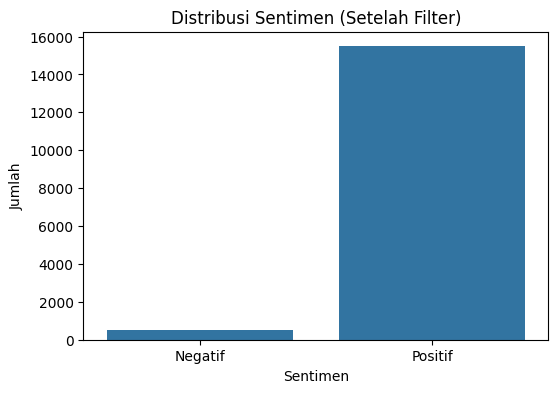

Jumlah data setelah preprocessing teks: 15982
Jumlah sampel per kelas mencukupi: {1: 15470, 0: 512}
Distribusi kelas sebelum ADASYN: Counter({np.int64(1): 12375, np.int64(0): 410})
ADASYN berhasil. Distribusi setelah ADASYN: Counter({np.int64(1): 12375, np.int64(0): 12284})


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5095 - loss: 0.6926
Epoch 1: val_loss improved from None to 0.60263, saving model to best_model_ADASYN_20260317_065908.keras

Epoch 1: finished saving model to best_model_ADASYN_20260317_065908.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5300 - loss: 0.6898 - val_accuracy: 0.9618 - val_loss: 0.6026
Epoch 2/15
374/386 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6028 - loss: 0.6658
Epoch 2: val_loss did not improve from 0.60263
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6220 - loss: 0.6521 - val_accuracy: 0.3672 - val_loss: 1.0736
Epoch 3/15
380/386 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6780 - loss: 0.6000
Epoch 3: val_loss improved from 0.60263 to 0.37128, saving model to best_model_ADASYN_20260317_065908.keras

Epoch 3: finished saving model to best_model_ADASYN_20260317_065908.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6877 - loss: 0.5885 - val_accuracy: 0.9199 

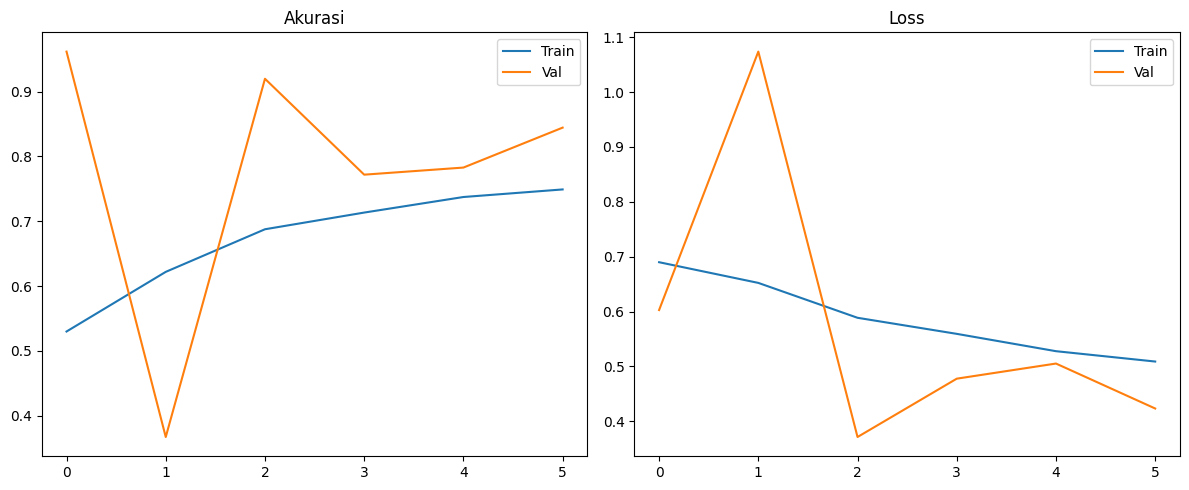

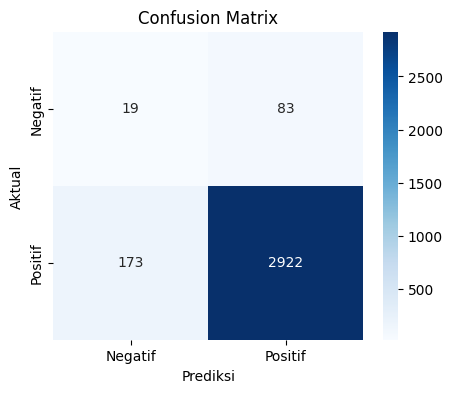


Laporan Klasifikasi:
              precision    recall  f1-score   support

     Negatif       0.10      0.19      0.13       102
     Positif       0.97      0.94      0.96      3095

    accuracy                           0.92      3197
   macro avg       0.54      0.57      0.54      3197
weighted avg       0.94      0.92      0.93      3197

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

HASIL PREDIKSI DATA BARU

Ulasan: I love this recipe! It was amazing and delicious.
Prediksi: Positif (probabilitas positif: 0.8217)
------------------------------------------------------------

Ulasan: This recipe was terrible, I hated it. Worst ever.
Prediksi: Positif (probabilitas positif: 0.7667)
------------------------------------------------------------

Ulasan: The recipe was okay, nothing special but edible.
Prediksi: Positif (probabilitas positif: 0.7729)
------------------------------------------------------------

Ulasan: Absolutely fantastic! Will make again.
Prediksi: Positif (probabilitas 

In [9]:
# =============================================================================
# PROGRAM KLASIFIKASI SENTIMEN ULASAN RESEP MENGGUNAKAN MLP DENGAN ADASYN
# =============================================================================
# Deskripsi:
# Program ini membangun model MLP untuk memprediksi sentimen positif/negatif dari ulasan resep.
# Data ulasan memiliki rating bintang; rating >=4 -> positif (1), rating <=2 -> negatif (0).
# Rating 3 (netral) diabaikan agar fokus pada klasifikasi biner.
# Ketidakseimbangan kelas ditangani dengan ADASYN (Adaptive Synthetic Sampling),
# sebuah metode oversampling adaptif yang menghasilkan sampel sintetis lebih banyak
# pada daerah yang sulit dipelajari. Overfitting dicegah dengan EarlyStopping dan
# ModelCheckpoint untuk menyimpan model terbaik.
#
# REKOMENDASI PERBAIKAN YANG DITERAPKAN:
# 1. Memisahkan proses fitting LabelEncoder hanya pada data training untuk menghindari
#    kebocoran informasi (data leakage) yang tidak disengaja.
# 2. Menambahkan callback ModelCheckpoint untuk menyimpan model terbaik berdasarkan
#    validasi loss, sehingga model yang disimpan adalah yang paling optimal selama pelatihan.
# 3. Validasi kecukupan data setelah preprocessing: memastikan jumlah sampel mencukupi
#    untuk pelatihan (minimal 10 sampel per kelas) dan memberikan pesan error yang jelas jika tidak.
# =============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SpatialDropout1D, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from imblearn.over_sampling import ADASYN
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datetime import datetime
import nltk
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 2. UNDUH RESOURCE NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 3. UPLOAD FILE CSV
print("Silakan unggah file CSV yang berisi dataset ulasan resep.")
uploaded = files.upload()
file_name = next(iter(uploaded))

try:
    data = pd.read_csv(file_name)
    print(f"File '{file_name}' berhasil dimuat. Dimensi data: {data.shape}")
except Exception as e:
    print(f"Error saat membaca file: {e}")
    raise

# 4. PREPROCESSING DATA
print("Kolom dalam dataset:", data.columns.tolist())

# Validasi kolom wajib
required_columns = ['text', 'stars']
for col in required_columns:
    if col not in data.columns:
        raise KeyError(f"Kolom '{col}' tidak ditemukan.")

# Hapus kolom tidak relevan (jika ada)
if 'Unnamed: 0' in data.columns:
    data_cleaned = data.drop(columns=['Unnamed: 0'])
else:
    data_cleaned = data.copy()

# Hapus missing values
if data_cleaned[['text', 'stars']].isnull().any().any():
    print("Menghapus baris dengan missing values...")
    data_cleaned = data_cleaned.dropna(subset=['text', 'stars'])

# Konversi stars ke numerik dan batasi rentang 1-5
data_cleaned['stars'] = pd.to_numeric(data_cleaned['stars'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['stars'])
data_cleaned = data_cleaned[(data_cleaned['stars'] >= 1) & (data_cleaned['stars'] <= 5)]

# 5. KONVERSI RATING KE SENTIMEN BINER
def rating_to_sentiment(rating):
    if rating >= 4:
        return 1
    elif rating <= 2:
        return 0
    else:
        return None  # rating 3 diabaikan

data_cleaned['sentiment'] = data_cleaned['stars'].apply(rating_to_sentiment)
data_cleaned = data_cleaned.dropna(subset=['sentiment']).reset_index(drop=True)
data_cleaned['sentiment'] = data_cleaned['sentiment'].astype(int)

# Pastikan kedua kelas tersedia
if len(data_cleaned['sentiment'].unique()) < 2:
    raise ValueError("Hanya satu kelas sentimen yang tersedia. Tidak dapat melanjutkan.")

# Visualisasi distribusi awal
plt.figure(figsize=(6,4))
sns.countplot(data=data_cleaned, x='sentiment')
plt.title('Distribusi Sentimen (Setelah Filter)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.xticks([0,1], ['Negatif', 'Positif'])
plt.show()

# 6. PREPROCESSING TEKS
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # hapus non-alfabet
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

data_cleaned['processed_text'] = data_cleaned['text'].apply(preprocess_text)
data_cleaned = data_cleaned[data_cleaned['processed_text'].str.strip() != ''].reset_index(drop=True)
print("Jumlah data setelah preprocessing teks:", len(data_cleaned))

# Validasi kecukupan data (minimal 10 sampel per kelas)
class_counts = data_cleaned['sentiment'].value_counts()
min_class_samples = class_counts.min()
if min_class_samples < 10:
    raise ValueError(f"Jumlah sampel per kelas terlalu sedikit: {class_counts.to_dict()}. Minimal diperlukan 10 sampel per kelas untuk pelatihan yang berarti.")
else:
    print("Jumlah sampel per kelas mencukupi:", class_counts.to_dict())

# 7. PERSIAPAN DATA UNTUK PELATIHAN
X = data_cleaned['processed_text']
y = data_cleaned['sentiment']

# Split data (stratify) terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit LabelEncoder HANYA pada data training (untuk menghindari data leakage)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  # transform menggunakan le yang sudah di-fit

# 8. TOKENISASI DAN PADDING
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)  # fit hanya pada training

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# 9. ADASYN (HANYA JIKA MEMUNGKINKAN)
print("Distribusi kelas sebelum ADASYN:", Counter(y_train_encoded))
min_samples = min(Counter(y_train_encoded).values())
if min_samples >= 2:
    adasyn = ADASYN(sampling_strategy='auto', random_state=42)
    X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_pad, y_train_encoded)
    print("ADASYN berhasil. Distribusi setelah ADASYN:", Counter(y_train_resampled))
else:
    print("Peringatan: Sampel minoritas <2, ADASYN tidak dapat diterapkan. Menggunakan data asli.")
    X_train_resampled, y_train_resampled = X_train_pad, y_train_encoded

# 10. MEMBANGUN MODEL MLP
model = Sequential([
    Embedding(input_dim=max_words, output_dim=100),  # input_length tidak diperlukan
    SpatialDropout1D(0.2),
    GlobalAveragePooling1D(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 11. CALLBACK: EARLY STOPPING DAN MODEL CHECKPOINT
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = f"best_model_ADASYN_{timestamp}.keras"

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 12. PELATIHAN
history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_pad, y_test_encoded),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# 13. SIMPAN MODEL AKHIR (opsional, karena yang terbaik sudah disimpan oleh checkpoint)
final_model_filename = f"final_model_ADASYN_{timestamp}.keras"
model.save(final_model_filename)
print(f"Model akhir disimpan sebagai: {final_model_filename}")

# 14. EVALUASI MENGGUNAKAN MODEL TERBAIK (load dari checkpoint)
from tensorflow.keras.models import load_model
best_model = load_model(checkpoint_path)

y_pred_prob = best_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

# Plot akurasi & loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Akurasi')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

print("\nLaporan Klasifikasi:")
print(classification_report(y_test_encoded, y_pred, target_names=['Negatif', 'Positif']))

# 15. PENGUJIAN DATA BARU
test_samples = [
    "I love this recipe! It was amazing and delicious.",
    "This recipe was terrible, I hated it. Worst ever.",
    "The recipe was okay, nothing special but edible.",
    "Absolutely fantastic! Will make again.",
    "Not good, too salty and bland."
]

test_processed = [preprocess_text(text) for text in test_samples]
for i, txt in enumerate(test_processed):
    if txt.strip() == '':
        print(f"Peringatan: Teks uji ke-{i+1} kosong.")

test_seq = tokenizer.texts_to_sequences(test_processed)
test_pad = pad_sequences(test_seq, maxlen=max_len)
test_pred_prob = best_model.predict(test_pad)
test_pred = (test_pred_prob > 0.5).astype(int).flatten()

print("\n" + "="*60)
print("HASIL PREDIKSI DATA BARU")
print("="*60)
for text, pred, prob in zip(test_samples, test_pred, test_pred_prob):
    sentiment = "Positif" if pred == 1 else "Negatif"
    print(f"\nUlasan: {text}")
    print(f"Prediksi: {sentiment} (probabilitas positif: {prob[0]:.4f})")
    print("-"*60)